# Tesseract

In [1]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install -q pytesseract opencv-python pillow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 148 not upgraded.


In [2]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

In [3]:
image_path = "/content/Capture.PNG"

In [5]:
image = cv2.imread(image_path)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
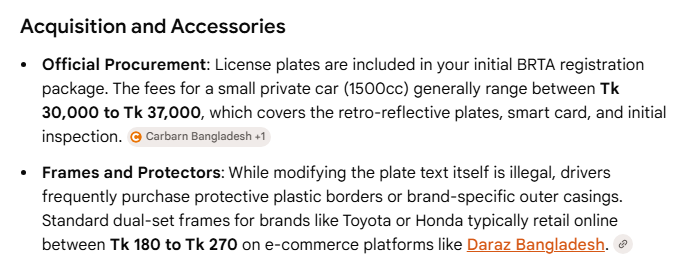

In [6]:
image

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
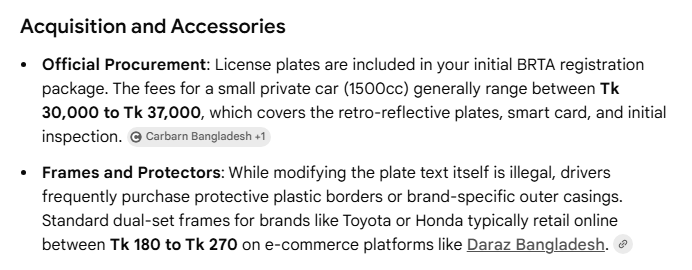

In [8]:
gray

In [9]:
# Extract text
text = pytesseract.image_to_string(
    gray,
    config="--oem 3 --psm 6"
)

print("Extracted Text:\n")
print(text)

Extracted Text:

Acquisition and Accessories

* Official Procurement: License plates are included in your initial BRTA registration
package. The fees for a small private car (1500cc) generally range between Tk
30,000 to Tk 37,000, which covers the retro-reflective plates, smart card, and initial
inspection. @ Carbarn Bangladesh «1

+ Frames and Protectors: While modifying the plate text itself is illegal, drivers
frequently purchase protective plastic borders or brand-specific outer casings.
Standard dual-set frames for brands like Toyota or Honda typically retail online
between Tk 180 to Tk 270 on e-commerce platforms like Daraz Bangladesh. @



# EasyOCR

In [10]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 26.4 MB/s eta 0:00:00


In [15]:
image_path = "/content/Capture.PNG"

In [16]:
import easyocr

In [17]:
# Create the OCR reader
# Set gpu=True to use Colab GPU when available
reader = easyocr.Reader(
    ["en"],
    gpu=False
)

In [18]:
results = reader.readtext(image_path)

In [19]:
print("Detected text:\n")

for bounding_box, text, confidence in results:
    print(f"Text: {text}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 30)

Detected text:

Text: Acquisition and Accessories
Confidence: 0.85
------------------------------
Text: Official Procurement: License plates are included in your initial BRTA registration
Confidence: 0.95
------------------------------
Text: package: The fees for
Confidence: 0.73
------------------------------
Text: small private car (150Occ) generally range between Tk
Confidence: 0.82
------------------------------
Text: 30,000 to Tk 37,000, which covers the retro-reflective plates, smart card, and initial
Confidence: 0.61
------------------------------
Text: inspection:
Confidence: 0.74
------------------------------
Text: Carbarn Bangladesh
Confidence: 1.00
------------------------------
Text: Frames and Protectors: While
Confidence: 0.84
------------------------------
Text: modifying the plate text itself is illegal, drivers
Confidence: 0.98
------------------------------
Text: frequently purchase protective plastic borders or brand-specific outer casings_
Confidence: 0.73
--------

In [20]:
results = reader.readtext(
    image_path,
    detail=0
)

extracted_text = "\n".join(results)

print(extracted_text)

Acquisition and Accessories
Official Procurement: License plates are included in your initial BRTA registration
package: The fees for
small private car (150Occ) generally range between Tk
30,000 to Tk 37,000, which covers the retro-reflective plates, smart card, and initial
inspection:
Carbarn Bangladesh
Frames and Protectors: While
modifying the plate text itself is illegal, drivers
frequently purchase protective plastic borders or brand-specific outer casings_
Standard dual-set frames for brands like Toyota or Honda typically retail online
between Tk 180 to Tk 270 on e-commerce platforms like Daraz Bangladesh:


# PaddleOCR

In [21]:
!pip install -q paddlepaddle==3.2.2
!pip install -q paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/

In [22]:
image_path = "/content/Capture.PNG"

In [23]:
from paddleocr import PaddleOCR

In [24]:
ocr = PaddleOCR(
    lang="en",
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [25]:
results = ocr.predict(image_path)

In [26]:
results

[{'input_path': '/content/Capture.PNG',
  'page_index': None,
  'doc_preprocessor_res': {'output_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], dtype=uint8)},
  'dt_polys': [array([[20, 18],
          ...,
          [20, 33]], dtype=int16),
   array([[39, 55],
          ...,
          [39, 73]], dtype=int16),
   array([[38, 79],
          ...,
          [38, 97]], dtype=int16),
   array([[ 38, 101],
          ...,
          [ 38, 119]], dtype=int16),
   array([[ 40, 129],
          ...,
          [ 40, 143]], dtype=int16),
   array([[ 40, 165],
          ...,
          [ 40, 179]], dtype=int16),
   array([[ 40, 189],
          ...,
          [ 40, 204]], dtype=int16),
   array([[ 38, 210],
          ...,
          [ 38, 228]], dtype=int16),
   array([[ 40, 236],
          ...,
          [ 40, 251]], dtype=int16)],
  'model_settings': {'use_doc_preprocessor': Fal

In [27]:
all_text = []

for result in results:
    data = result.json

    # Some PaddleOCR versions wrap the result inside "res"
    if "res" in data:
        data = data["res"]

    texts = data.get("rec_texts", [])
    scores = data.get("rec_scores", [])

    for text, score in zip(texts, scores):
        print(f"{text} | Confidence: {float(score):.2f}")
        all_text.append(text)

extracted_text = "\n".join(all_text)

print("\nComplete extracted text:\n")
print(extracted_text)

Acquisition and Accessories | Confidence: 0.98
Official Procurement: License plates are included in your initial BRTA registration | Confidence: 1.00
package. The fees for a small private car (15oOcc) generally range between Tk | Confidence: 0.98
30,000 to Tk 37,000, which covers the retro-reflective plates, smart card, and initial | Confidence: 0.99
inspection.Carbarn Bangladesh +1 | Confidence: 1.00
Frames and Protectors: While modifying the plate text itself is illegal, drivers | Confidence: 1.00
frequently purchase protective plastic borders or brand-specific outer casings. | Confidence: 1.00
Standard dual-set frames for brands like Toyota or Honda typically retail online | Confidence: 1.00
between Tk 180 to Tk 270 on e-commerce platforms like Daraz Bangladesh. | Confidence: 1.00

Complete extracted text:

Acquisition and Accessories
Official Procurement: License plates are included in your initial BRTA registration
package. The fees for a small private car (15oOcc) generally range